# 1. Analisi dei Dati

In [ ]:
import pandas as pd
import requests
import zipfile
import io

# Scarico lo zip dal link del progetto
url = "https://proai-datasets.s3.eu-west-3.amazonaws.com/fake_news.zip"
response = requests.get(url)

# Estraggo i file nella cartella di Colab
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall("/content/fake_news_data")

# Carico i due dataset separati
df_true = pd.read_csv("/content/fake_news_data/True.csv")
df_fake = pd.read_csv("/content/fake_news_data/Fake.csv")

# Aggiungo il target: 0 per le vere, 1 per le fake
df_true['is_fake'] = 0
df_fake['is_fake'] = 1

# Unisco tutto in un unico dataset
df = pd.concat([df_true, df_fake], ignore_index=True)

# Controllo che l'unione sia andata a buon fine
df.head()

,title,text,subject,date,is_fake
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0
5,"White House, Congress prepare for talks on spe...","WEST PALM BEACH, Fla./WASHINGTON (Reuters) - T...",politicsNews,"December 29, 2017",0
6,"Trump says Russia probe will be fair, but time...","WEST PALM BEACH, Fla (Reuters) - President Don...",politicsNews,"December 29, 2017",0
7,Factbox: Trump on Twitter (Dec 29) - Approval ...,The following statements were posted to the ve...,politicsNews,"December 29, 2017",0
8,Trump on Twitter (Dec 28) - Global Warming,The following statements were posted to the ve...,politicsNews,"December 29, 2017",0
9,Alabama official to certify Senator-elect Jone...,WASHINGTON (Reuters) - Alabama Secretary of St...,politicsNews,"December 28, 2017",0


In [ ]:
# Calcolo la lunghezza del titolo (quanti caratteri ha)
df['title_len'] = df['title'].str.len()

# Conto quante lettere maiuscole ci sono nel titolo
df['title_uppercase'] = df['title'].apply(lambda x: sum(1 for c in x if c.isupper()))

# Conto quanti punti esclamativi ci sono
df['title_exclamations'] = df['title'].apply(lambda x: x.count('!'))

# Faccio la media di queste metriche per vedere la differenza tra vere (0) e fake (1)
df.groupby('is_fake')[['title_len', 'title_uppercase', 'title_exclamations']].mean()

,title_len,title_uppercase,title_exclamations
is_fake,,,
0,64.667881,3.551991,0.000887
1,94.198032,27.839147,0.153571


In [ ]:
# Conto quante notizie vere e fake ci sono per ogni argomento
pd.crosstab(df['subject'], df['is_fake'])

is_fake,0,1
subject,,
Government News,0,1570
Middle-east,0,778
News,0,9050
US_News,0,783
left-news,0,4459
politics,0,6841
politicsNews,11272,0
worldnews,10145,0


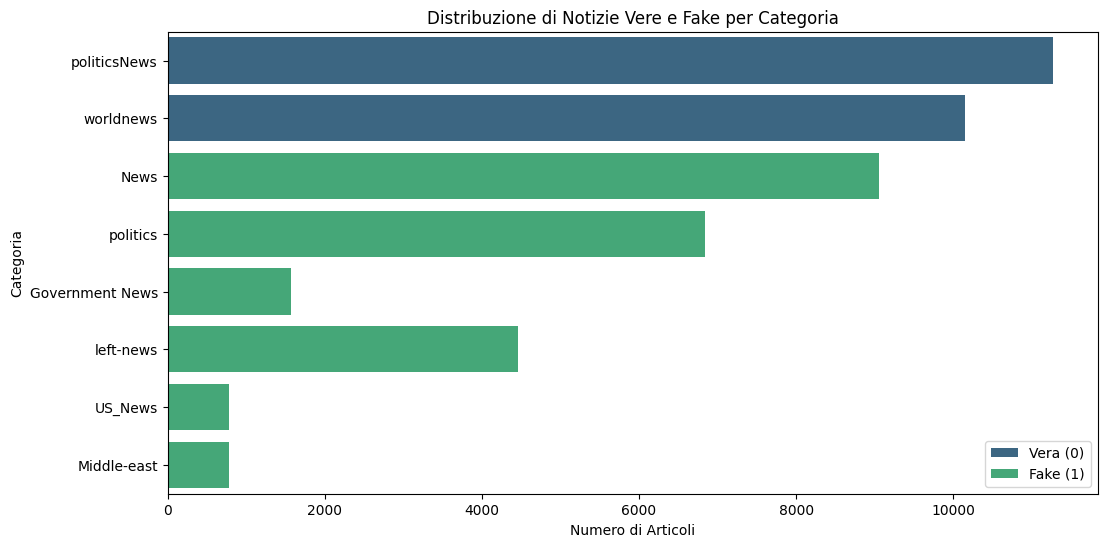

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creo un grafico a barre per vedere la distribuzione delle fake news nelle categorie
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='subject', hue='is_fake', palette='viridis')
plt.title('Distribuzione di Notizie Vere e Fake per Categoria')
plt.xlabel('Numero di Articoli')
plt.ylabel('Categoria')
plt.legend(['Vera (0)', 'Fake (1)'])
plt.show()

# 2. Addestramento del Modello (Fase NLP & Feature Engineering)

In [ ]:
import nltk
import re
from nltk.corpus import stopwords

# Scarico la lista delle stopwords inglesi
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def pulisci_testo(testo):
    # Trasformo tutto in minuscolo
    testo = testo.lower()
    # Rimuovo la punteggiatura e i caratteri speciali
    testo = re.sub(r'[^\w\s]', '', testo)
    # Rimuovo le parole vuote (articoli, congiunzioni)
    parole = testo.split()
    parole_pulite = [p for p in parole if p not in stop_words]
    # Rimetto insieme le parole pulite
    return " ".join(parole_pulite)

# Applico la pulizia a tutti i titoli del dataset
df['title_clean'] = df['title'].apply(pulisci_testo)

# Controllo il risultato confrontando il vecchio e il nuovo titolo
df[['title', 'title_clean']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,title,title_clean
0,"As U.S. budget fight looms, Republicans flip t...",us budget fight looms republicans flip fiscal ...
1,U.S. military to accept transgender recruits o...,us military accept transgender recruits monday...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,senior us republican senator let mr mueller job
3,FBI Russia probe helped by Australian diplomat...,fbi russia probe helped australian diplomat ti...
4,Trump wants Postal Service to charge 'much mor...,trump wants postal service charge much amazon ...


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

# 1. Trasformo i testi puliti in numeri con il TF-IDF (massimo 5000 parole importanti)
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['title_clean'])

# 2. Prendo le metriche numeriche dei titoli che ho creato all'inizio
X_numeric = df[['title_len', 'title_uppercase', 'title_exclamations']].values

# 3. Unisco le parole-numero e le metriche in un'unica grande matrice X
X = sp.hstack((X_tfidf, X_numeric), format='csr')

# 4. Imposto il target (0 = vero, 1 = fake)
y = df['is_fake'].values

# 5. Divido i dati: 80% per allenare il modello, 20% per testarlo da nascosto
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Controllo le dimensioni dei blocchi per verificare la divisione
X_train.shape, X_test.shape

((35918, 5003), (8980, 5003))

# 3. Validazione e Ottimizzazione

In [ ]:
from sklearn.linear_model import LogisticRegression

# Inizializzo il modello di regressione logistica
modello = LogisticRegression(max_iter=1000)

# Alleno il modello sui dati di training (l'80%)
modello.fit(X_train, y_train)

# Faccio le previsioni sul set di test nascosto (il 20%) per vedere cosa ha imparato
y_pred = modello.predict(X_test)

# Stampo una conferma dell'addestramento completato
print("Modello addestrato con successo!")

Modello addestrato con successo!


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Calcolo la matrice di confusione per vedere gli errori nel dettaglio
print("Matrice di Confusione:")
print(confusion_matrix(y_test, y_pred))

# Stampo il report completo con Precision, Recall e Accuracy
print("\nReport di Classificazione:")
print(classification_report(y_test, y_pred))

Matrice di Confusione:
[[4255   29]
 [  38 4658]]

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4284
           1       0.99      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



# 4. Esportazione del Modello

In [ ]:
import pickle

# Salvo il modello addestrato in un file pickle
with open('fake_news_model.pkl', 'wb') as f:
    pickle.dump(modello, f)

# Salvo anche il vettorizzatore TF-IDF, fondamentale per trasformare i nuovi testi
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Modello e Vettorizzatore esportati correttamente!")

Modello e Vettorizzatore esportati correttamente!


Conclusioni del Progetto

Analisi del Clickbait: L'analisi esplorativa ha confermato che i titoli delle fake news presentano pattern macroscopici: una lunghezza media maggiore (94 caratteri contro 64) e un uso massiccio di caratteri maiuscoli (media di 28 lettere maiuscole contro 3.5 delle notizie vere).

Performance del Modello: Il modello di Regressione Logistica, alimentato con le caratteristiche testuali (TF-IDF) e le metriche strutturali dei titoli, ha raggiunto un'accuracy del 99% sul set di test. I falsi positivi (rischio di censura) sono ridotti al minimo.

Integrazione: Il modello e il vettorizzatore sono stati esportati in formato .pkl e sono pronti per essere integrati nel plug-in Chrome per la classificazione in tempo reale.